In [2]:
import torchvision
import numpy as np
import matplotlib.pyplot as plt


from torchvision.transforms import PILToTensor
from matplotlib.patches import Rectangle

In [3]:
dataset = torchvision.datasets.Kitti(
    root="./data",
    transform=PILToTensor(),
    download=True
)

In [4]:
len(dataset)

7481

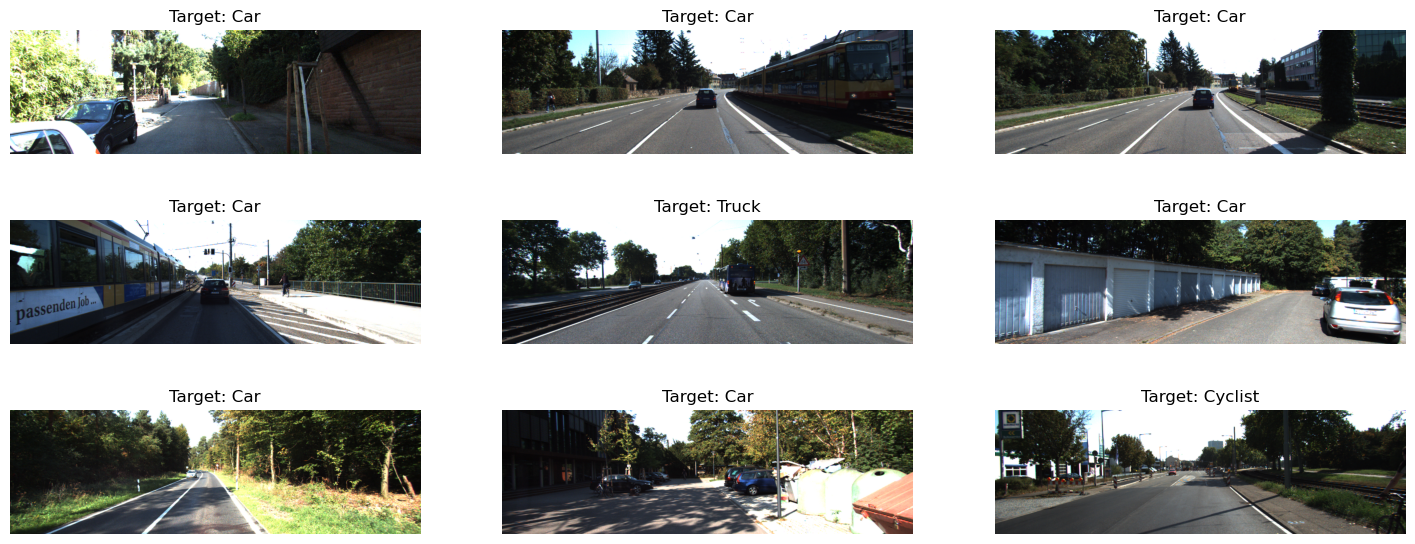

In [5]:
import random

fig, axes = plt.subplots(3, 3, figsize=(18, 7))
axes = axes.flatten()


for i, ax in enumerate(axes):
    random_int = random.randint(0, 7480)
    img, target = dataset[random_int]

    ax.imshow(img.permute(1, 2, 0))
    ax.set_title("Target: " + target[0]["type"])
    ax.axis("off")

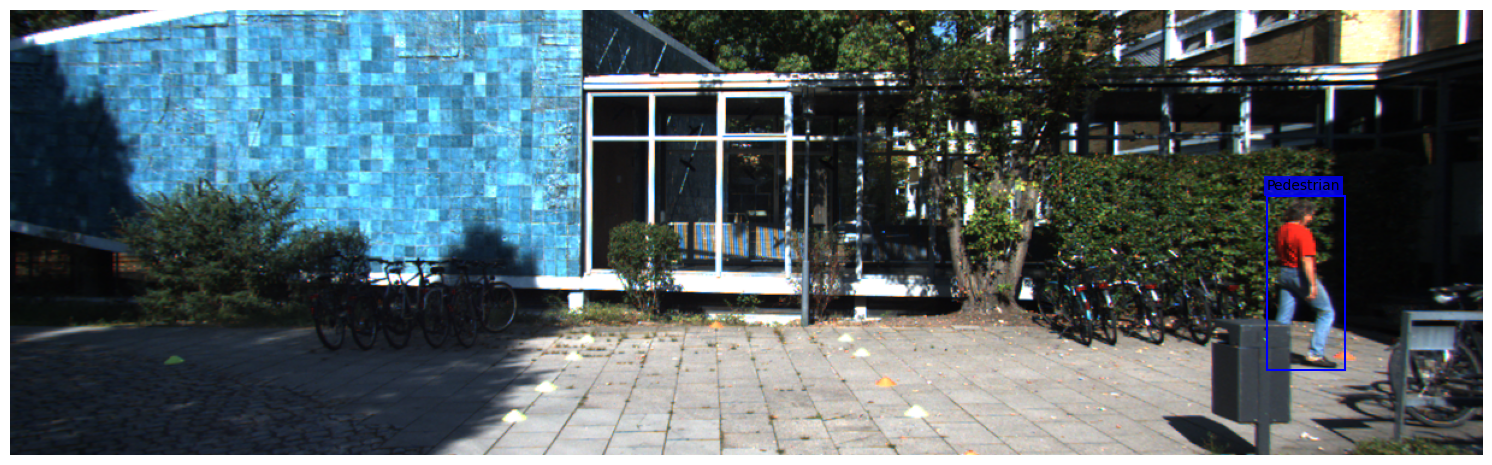

In [13]:
random_int = random.randint(0, 7480)
img, targets = dataset[random_int]

img = img.permute(1, 2, 0)

fig, ax = plt.subplots(figsize=(19,9))
ax.imshow(img)
ax.axis("Off")

color_map = {
    "Car": "red",
    "Pedestrian": "blue",
    "Cyclist": "green",
    "Van": "orange",
    "Truck": "yellow"
}

for obj in targets:
    left, top, right, bottom = obj["bbox"]

    width = right - left
    height = bottom - top

    box_color = color_map.get(obj["type"], "white")
    
    rectangle = Rectangle(
        (left, top),
        width,
        height,
        fill=False,
        color=box_color,
        linewidth=1.5
    )

    ax.add_patch(rectangle)

    if obj["type"] != "DontCare":
        ax.text(
        left,
        top - 5,
        obj["type"],
        fontsize=10,
        color="black",
        bbox={
            "facecolor": box_color,
            "alpha": 0.8,
            "edgecolor": "none",
            "pad": 2
        }
    )